In [3]:
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import pydicom

In [19]:
ROOTS = [
    Path(r"D:\Downloads\manifest-ZkhPvrLo5216730872708713142\CBIS-DDSM"),
    Path(r"G:\CBIS-DDSM"),
]
METADATA_CSV = Path(r"D:\Downloads\manifest-ZkhPvrLo5216730872708713142\metadata.csv")
PNG_ROOT = Path(r"D:\CBIS-DDSM-PNG")

In [21]:
def read_dicom_pixels(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    arr = ds.pixel_array
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    if slope != 1.0 or intercept != 0.0:
        arr = arr.astype(np.float64) * slope + intercept
    if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
        bits = int(getattr(ds, "BitsStored", 16))
        arr = ((2 ** bits) - 1) - arr
    return arr.astype(np.uint16)

In [23]:
def save_png16(arr16, out_path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), arr16, [cv2.IMWRITE_PNG_COMPRESSION, 6])


def pick_mask_and_crop(dcm_paths):
    if len(dcm_paths) == 1:
        return dcm_paths[0], None
    scored = []
    for p in dcm_paths:
        ds = pydicom.dcmread(p)
        arr = ds.pixel_array
        is_uint16 = (arr.dtype == np.uint16) or (int(getattr(ds, "BitsAllocated", 8)) == 16)
        n_unique = len(np.unique(arr))
        scored.append((is_uint16, n_unique, p))
    scored.sort(key=lambda t: (t[0], t[1]))
    mask_path = scored[0][2]
    crop_path = scored[1][2] if len(scored) > 1 else None
    return mask_path, crop_path

In [25]:
def resolve_series_dir(file_location, roots):
    rel = Path(str(file_location).lstrip(".\\/"))
    parts = rel.parts
    if parts and parts[0].lower() == "cbis-ddsm":
        parts = parts[1:]
    for root in roots:
        candidate = root.joinpath(*parts)
        if candidate.exists():
            return candidate
    return None


In [27]:
import os

def get_already_converted_uids(png_root):
    """Check disk directly, not just the log — survives a log that wasn't saved before a crash."""
    done = set()
    if not png_root.exists():
        return done
    for uid_dir in os.listdir(png_root):
        full_path = png_root / uid_dir
        if not full_path.is_dir():
            continue
        files = os.listdir(full_path)
        # consider it done if it has a full.png OR both mask.png+crop.png (or just mask.png alone)
        if "full.png" in files or "mask.png" in files:
            done.add(uid_dir)
    return done

In [29]:
def convert_all(metadata_csv, roots, png_root, resume=True):
    log_rows = []
    meta = pd.read_csv(metadata_csv)
    n_total = len(meta)

    already_done_uids = set()
    if resume:
        already_done_uids = get_already_converted_uids(png_root)
        print(f"Resuming: {len(already_done_uids)} UIDs already on disk, skipping those")

        # also fold in whatever was in the log, in case it has entries disk-check misses
        existing_log_path = png_root / "conversion_log.csv"
        if existing_log_path.exists():
            prior_log = pd.read_csv(existing_log_path)
            log_rows = prior_log.to_dict("records")

    for i, row in meta.iterrows():
        uid = str(row["Series UID"])
        if uid in already_done_uids:
            continue

        desc = str(row["Series Description"]).lower()
        series_dir = resolve_series_dir(row["File Location"], roots)
        if series_dir is None:
            print(f"WARNING: not found on any root — {row['File Location']}")
            continue

        dcm_files = sorted(series_dir.glob("*.dcm"))
        if not dcm_files:
            print(f"WARNING: no .dcm files in {series_dir}")
            continue

        try:
            if "full mammogram" in desc:
                arr16 = read_dicom_pixels(dcm_files[0])
                out = png_root / uid / "full.png"
                save_png16(arr16, out)
                log_rows.append({"uid": uid, "role": "full", "path": str(out)})

            elif "roi mask" in desc:
                mask_p, crop_p = pick_mask_and_crop(dcm_files)
                arr16 = read_dicom_pixels(mask_p)
                out = png_root / uid / "mask.png"
                save_png16(arr16, out)
                log_rows.append({"uid": uid, "role": "mask", "path": str(out)})
                if crop_p:
                    arr16c = read_dicom_pixels(crop_p)
                    outc = png_root / uid / "crop.png"
                    save_png16(arr16c, outc)
                    log_rows.append({"uid": uid, "role": "crop", "path": str(outc)})
        except Exception as e:
            print(f"ERROR on {series_dir}: {e}")
            continue

        if i % 200 == 0:
            print(f"  {i}/{n_total} metadata rows processed")
            pd.DataFrame(log_rows).to_csv(existing_log_path, index=False)

    png_root.mkdir(parents=True, exist_ok=True)
    log_df = pd.DataFrame(log_rows)
    log_df.to_csv(existing_log_path, index=False)
    print(f"\nDone. Total converted: {len(log_df)}")
    print(f"Log: {existing_log_path}")
    return log_df

print("All functions defined.")

All functions defined.


In [37]:
log_df = convert_all(METADATA_CSV, ROOTS, PNG_ROOT)

Resuming: 6668 UIDs already on disk, skipping those

Done. Total converted: 6904
Log: D:\CBIS-DDSM-PNG\conversion_log.csv


In [55]:
log_df = pd.read_csv(r"D:\CBIS-DDSM-PNG\conversion_log.csv")
print(len(log_df), "total converted images")
print(log_df["role"].value_counts())

meta = pd.read_csv(METADATA_CSV)
print("Expected full mammogram rows:", (meta["Series Description"] == "full mammogram images").sum())
print("Expected ROI mask rows:", (meta["Series Description"] == "ROI mask images").sum())

10129 total converted images
role
mask    3565
crop    3461
full    3103
Name: count, dtype: int64
Expected full mammogram rows: 3105
Expected ROI mask rows: 3568


# Validation (Sanity Check Codes)

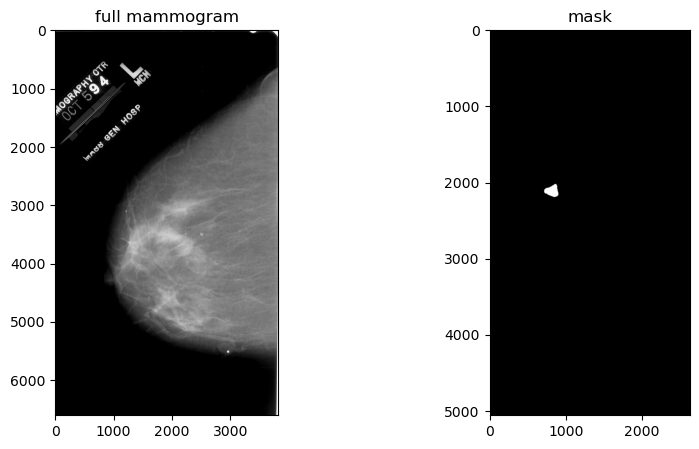

full dtype/shape check: uint16


In [51]:
import matplotlib.pyplot as plt

sample_full = pd.read_csv(r"D:\CBIS-DDSM-PNG\conversion_log.csv")
full_row = sample_full[sample_full.role == "full"].iloc[0]
mask_row = sample_full[sample_full.role == "mask"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(plt.imread(full_row["path"]), cmap="gray")
axes[0].set_title("full mammogram")
axes[1].imshow(plt.imread(mask_row["path"]), cmap="gray")
axes[1].set_title("mask")
plt.show()

print("full dtype/shape check:", cv2.imread(full_row["path"], cv2.IMREAD_UNCHANGED).dtype)